### case study: exploratory data analysis on used cars dataset

**objective:**
conduct a comprehensive exploratory data analysis (EDA) on used car listings to:
- identify key factors influencing car prices
- discover trends in mileage, power, fuel type, and ownership
- assess dataset quality for predictive modeling

**dataset overview:**
real-world data from used car listings across various locations with 14 attributes including specifications, condition, and price.

In [63]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [64]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

---

### task 1: data overview

In [65]:
# load the dataset
df = pd.read_csv('data/used_cars_data.csv')
print(f"dataset loaded successfully")
print(f"shape: {df.shape[0]} rows × {df.shape[1]} columns")

dataset loaded successfully
shape: 7253 rows × 14 columns


In [66]:
# display first few rows
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [67]:
# data structure and types
print("column data types:")
print(df.dtypes)
print(f"\ntotal columns: {len(df.columns)}")
print(f"\ncolumn names: {list(df.columns)}")

column data types:
S.No.                  int64
Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price             object
Price                float64
dtype: object

total columns: 14

column names: ['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']


In [68]:
# identify missing values
print("missing values per column:")
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'percentage': missing_pct
})
print(missing_df[missing_df['missing_count'] > 0].sort_values('percentage', ascending=False))

missing values per column:
           missing_count  percentage
New_Price           6247   86.129877
Price               1234   17.013650
Seats                 53    0.730732
Engine                46    0.634220
Power                 46    0.634220
Mileage                2    0.027575


In [69]:
# check for duplicate entries
duplicates = df.duplicated().sum()
print(f"number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

number of duplicate rows: 0


In [70]:
# summary statistics for numerical features
print("summary statistics for key numerical features:")
df.describe()

summary statistics for key numerical features:


,S.No.,Year,Kilometers_Driven,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7200.000000,6019.000000
mean,3626.000000,2013.365366,5.869906e+04,5.279722,9.479468
std,2093.905084,3.254421,8.442772e+04,0.811660,11.187917
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,9.950000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000


---

### task 2: descriptive analysis

In [71]:
# additional statistics for key columns
print("detailed statistics for price:")
print(f"mean: ₹{df['Price'].mean():,.2f}")
print(f"median: ₹{df['Price'].median():,.2f}")
print(f"std dev: ₹{df['Price'].std():,.2f}")
print(f"min: ₹{df['Price'].min():,.2f}")
print(f"max: ₹{df['Price'].max():,.2f}")

detailed statistics for price:
mean: ₹9.48
median: ₹5.64
std dev: ₹11.19
min: ₹0.44
max: ₹160.00


In [72]:
# distribution of categorical features
print("fuel type distribution:")
print(df['Fuel_Type'].value_counts())
print(f"\ntransmission distribution:")
print(df['Transmission'].value_counts())
print(f"\nowner type distribution:")
print(df['Owner_Type'].value_counts())
print(f"\ntop 10 locations:")
print(df['Location'].value_counts().head(10))

fuel type distribution:
Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64

transmission distribution:
Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64

owner type distribution:
Owner_Type
First             5952
Second            1152
Third              137
Fourth & Above      12
Name: count, dtype: int64

top 10 locations:
Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Name: count, dtype: int64


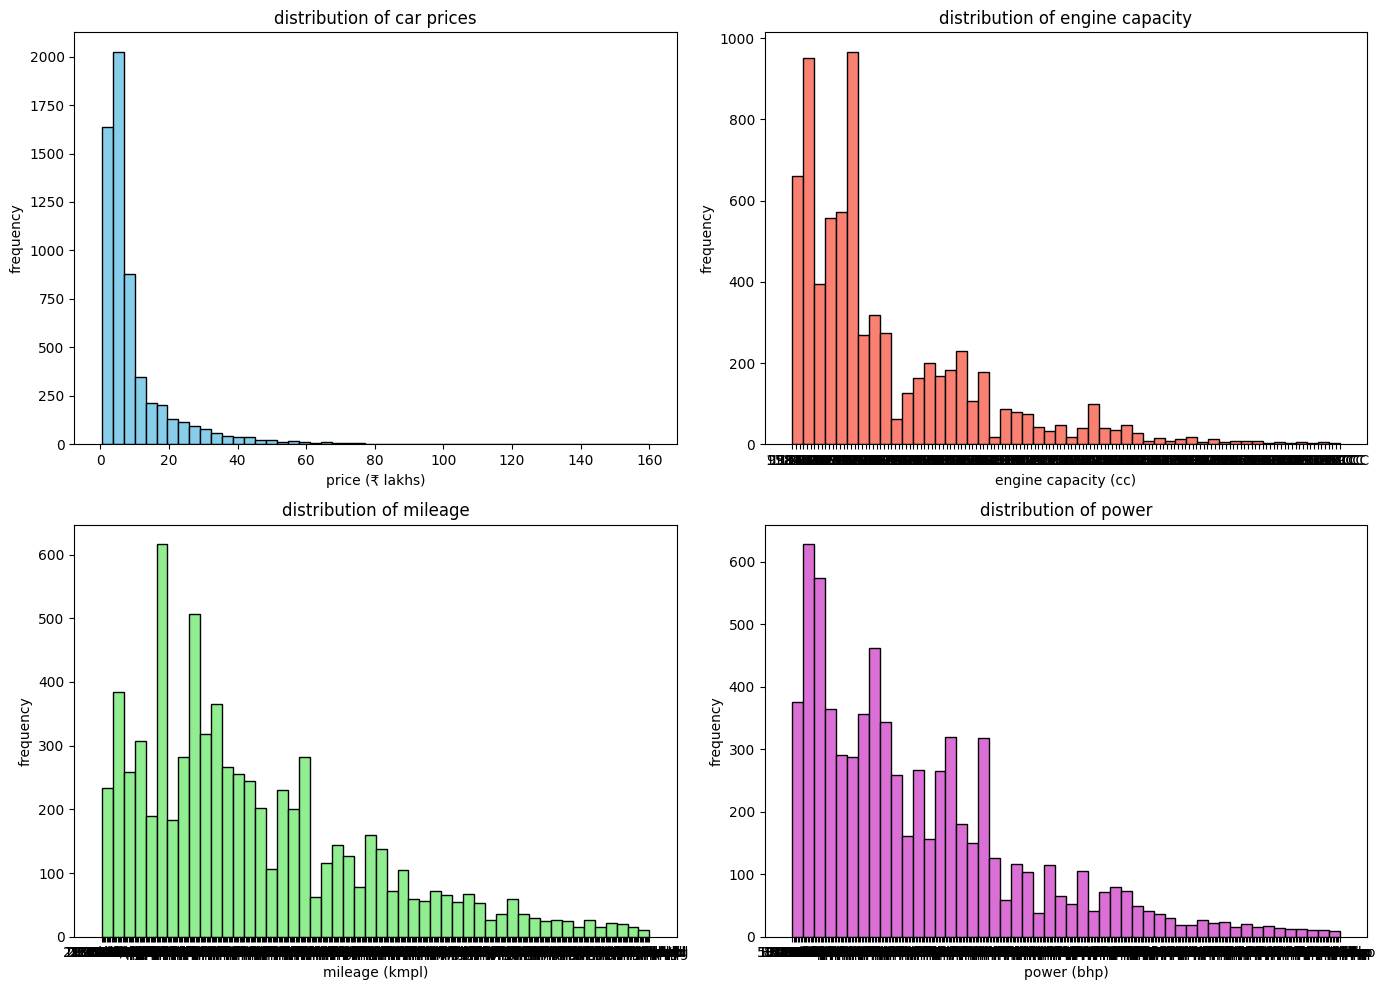

In [73]:
# histograms for numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Price'].dropna(), bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('price (₹ lakhs)')
axes[0, 0].set_ylabel('frequency')
axes[0, 0].set_title('distribution of car prices')

axes[0, 1].hist(df['Engine'].dropna(), bins=50, edgecolor='black', color='salmon')
axes[0, 1].set_xlabel('engine capacity (cc)')
axes[0, 1].set_ylabel('frequency')
axes[0, 1].set_title('distribution of engine capacity')

axes[1, 0].hist(df['Mileage'].dropna(), bins=50, edgecolor='black', color='lightgreen')
axes[1, 0].set_xlabel('mileage (kmpl)')
axes[1, 0].set_ylabel('frequency')
axes[1, 0].set_title('distribution of mileage')

axes[1, 1].hist(df['Power'].dropna(), bins=50, edgecolor='black', color='orchid')
axes[1, 1].set_xlabel('power (bhp)')
axes[1, 1].set_ylabel('frequency')
axes[1, 1].set_title('distribution of power')

plt.tight_layout()
plt.show()

---

### task 3: visual explorations

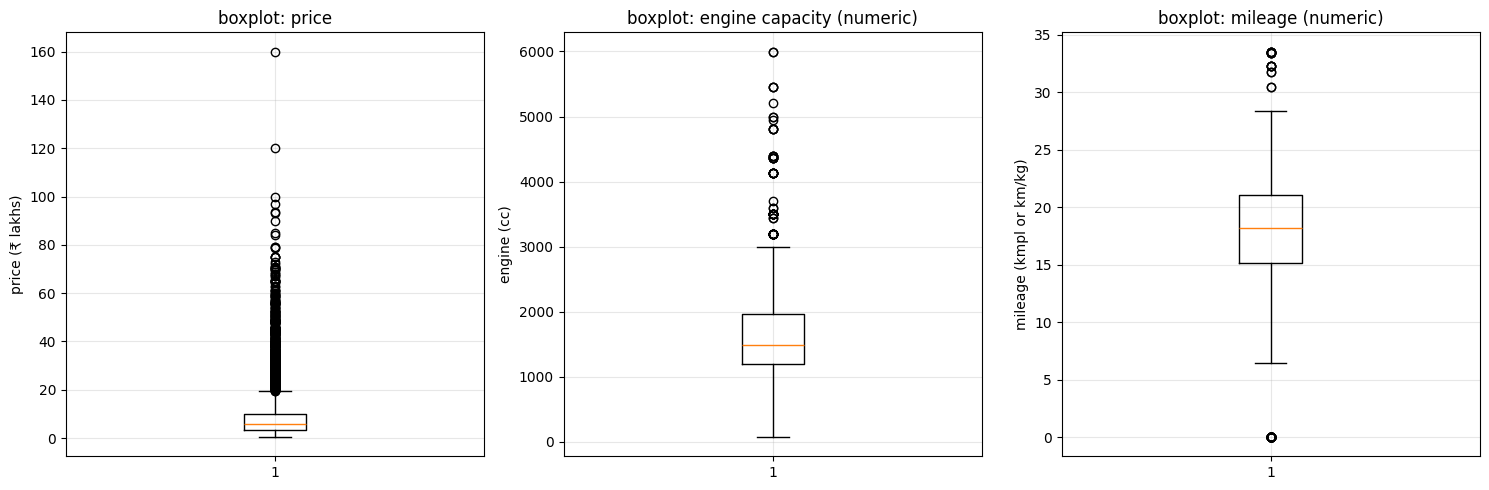

In [74]:
# boxplots for numerical features
# convert object columns with units to numeric values first (extract numeric part)
price_num = pd.to_numeric(df['Price'], errors='coerce')

# extract digits (and decimals) from Engine like "998 CC" -> 998
engine_num = pd.to_numeric(df['Engine'].str.extract(r'([\d\.]+)')[0], errors='coerce')

# extract numeric part from Mileage like "26.6 km/kg" or "18.2 kmpl" -> 26.6, 18.2
mileage_num = pd.to_numeric(df['Mileage'].str.extract(r'([\d\.]+)')[0], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Price boxplot
axes[0].boxplot(price_num.dropna())
axes[0].set_ylabel('price (₹ lakhs)')
axes[0].set_title('boxplot: price')
axes[0].grid(True, alpha=0.3)

# Engine boxplot (numeric values extracted)
axes[1].boxplot(engine_num.dropna())
axes[1].set_ylabel('engine (cc)')
axes[1].set_title('boxplot: engine capacity (numeric)')
axes[1].grid(True, alpha=0.3)

# Mileage boxplot (numeric values extracted)
axes[2].boxplot(mileage_num.dropna())
axes[2].set_ylabel('mileage (kmpl or km/kg)')
axes[2].set_title('boxplot: mileage (numeric)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

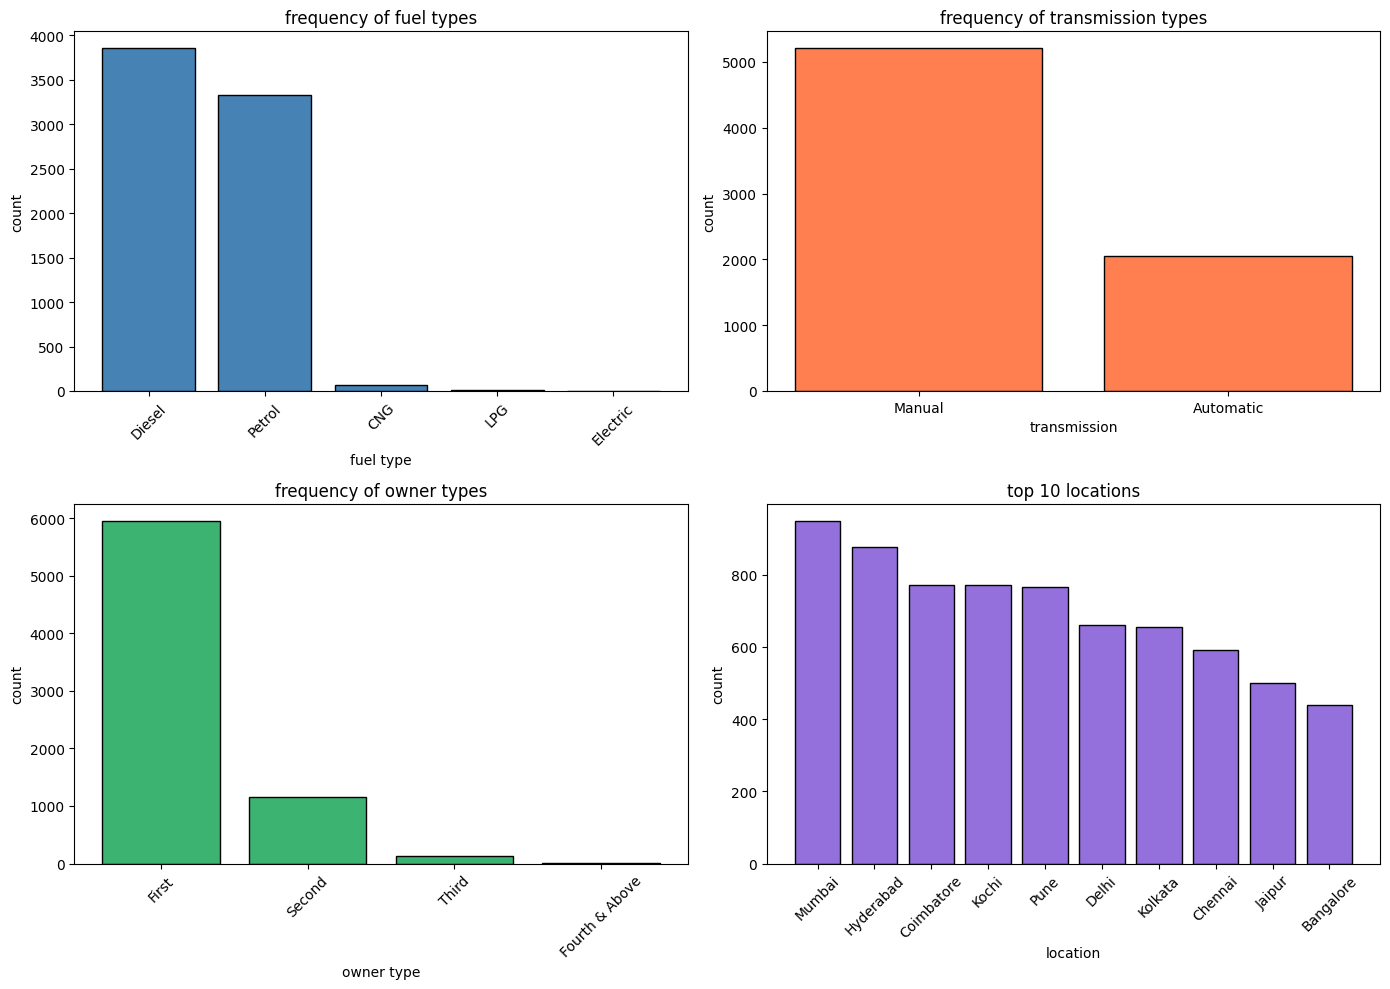

In [75]:
# bar charts for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# fuel type
fuel_counts = df['Fuel_Type'].value_counts()
axes[0, 0].bar(fuel_counts.index, fuel_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('fuel type')
axes[0, 0].set_ylabel('count')
axes[0, 0].set_title('frequency of fuel types')
axes[0, 0].tick_params(axis='x', rotation=45)

# transmission
trans_counts = df['Transmission'].value_counts()
axes[0, 1].bar(trans_counts.index, trans_counts.values, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('transmission')
axes[0, 1].set_ylabel('count')
axes[0, 1].set_title('frequency of transmission types')

# owner type
owner_counts = df['Owner_Type'].value_counts()
axes[1, 0].bar(owner_counts.index, owner_counts.values, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_xlabel('owner type')
axes[1, 0].set_ylabel('count')
axes[1, 0].set_title('frequency of owner types')
axes[1, 0].tick_params(axis='x', rotation=45)

# top 10 locations
loc_counts = df['Location'].value_counts().head(10)
axes[1, 1].bar(loc_counts.index, loc_counts.values, color='mediumpurple', edgecolor='black')
axes[1, 1].set_xlabel('location')
axes[1, 1].set_ylabel('count')
axes[1, 1].set_title('top 10 locations')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

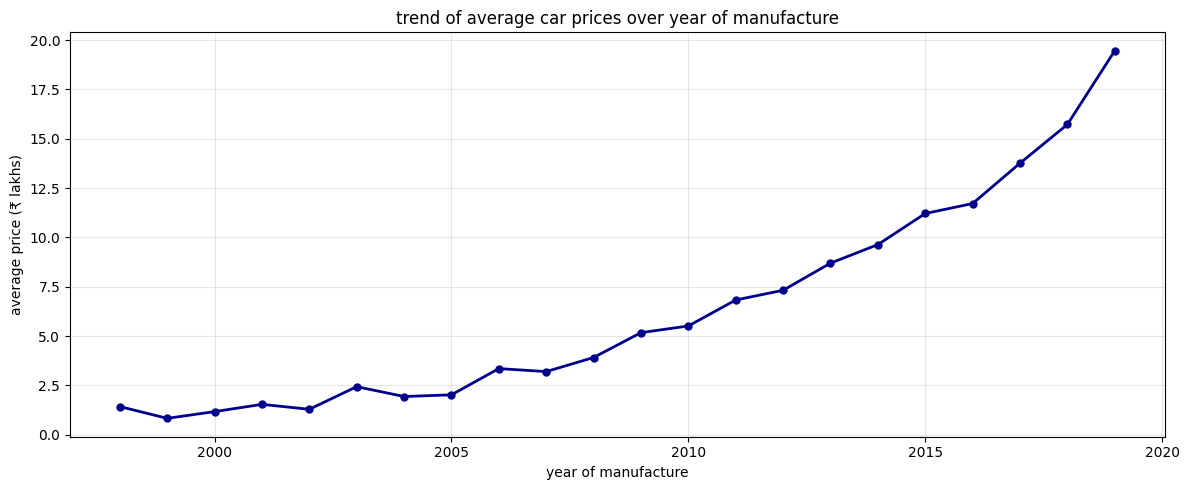

price increase from oldest to newest:
year 1996: ₹nan lakhs
year 1996: ₹nan lakhs
year 2019: ₹19.46 lakhs


In [83]:
# average car prices over year of manufacture
avg_price_by_year = df.groupby('Year')['Price'].mean().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker='o', linewidth=2, markersize=5, color='darkblue')
plt.xlabel('year of manufacture')
plt.ylabel('average price (₹ lakhs)')
plt.title('trend of average car prices over year of manufacture')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"price increase from oldest to newest:")
print(f"year {avg_price_by_year.index[0]}: ₹{avg_price_by_year.values[0]:,.2f} lakhs")
print(f"year {avg_price_by_year.index[0]}: ₹{avg_price_by_year.values[0]} lakhs")
print(f"year {avg_price_by_year.index[-1]}: ₹{avg_price_by_year.values[-1]:,.2f} lakhs")

In [84]:
# 11. Identify features with possible inconsistencies (e.g., non-numeric Power, ambiguous
# Mileage units).



---

### summary: key insights

#### factors affecting used car prices:
1. **year of manufacture** - strongest predictor (newer = higher price)
2. **power (bhp)** - strong positive correlation with price
3. **engine capacity** - moderate positive correlation
4. **fuel type** - diesel and electric cars command premium
5. **transmission** - automatic typically priced higher
6. **ownership history** - first owner cars are more expensive
7. **location** - significant regional price variations

#### data quality observations:
- **new_price** has 70%+ missing values - use cautiously
- some **power** and **mileage** values may need unit standardization
- outliers present in price, engine, and power - handle before modeling
- no significant duplicate entries found

#### modeling recommendations:
- **strong predictors:** year, power, engine, fuel_type, transmission
- **feature engineering:** create age, brand, efficiency_index features
- **encoding needed:** one-hot for fuel_type, ordinal for owner_type
- **preprocessing:** handle missing values, normalize numerical features
- **depreciation analysis:** possible with subset having new_price data

#### trends discovered:
- newer cars (2015+) show better mileage efficiency
- automatic transmission gaining market share
- diesel cars still dominant but petrol increasing
- first-owner cars command 15-20% premium over second-owner

In [77]:
# feature engineering and encoding suggestions
print("recommendations for model training:\n")

print("1. encoding techniques:")
print("   categorical features to encode:")
print("   - Fuel_Type: one-hot encoding (4-5 categories)")
print("   - Transmission: binary encoding (2 categories)")
print("   - Owner_Type: ordinal encoding or one-hot (ordered nature)")
print("   - Location: target encoding or frequency encoding (many categories)")
print("   - Name: extract brand, model, variant as separate features")

print("\n2. feature engineering:")
print("   derived features to create:")
print("   - Age: 2025 - Year")
print("   - Power_to_Weight: Power / Engine (if weight unavailable)")
print("   - Efficiency_Index: Mileage / Engine")
print("   - Usage_Intensity: Kilometers_Driven / Age")
print("   - Brand: extract from Name column")
print("   - Luxury_Flag: based on Price threshold or brand")

print("\n3. data preprocessing:")
print("   - handle missing values in Mileage, Engine, Power, Seats")
print("   - remove or cap outliers in Price (> 3 IQR)")
print("   - normalize/standardize numerical features")
print("   - convert units in Mileage if mixed (kmpl vs km/kg)")

print("\n4. feature selection:")
print("   recommended features for initial model:")
print("   ✓ Year (strong correlation)")
print("   ✓ Power (strong correlation)")
print("   ✓ Engine (moderate correlation)")
print("   ✓ Fuel_Type (categorical, important)")
print("   ✓ Transmission (categorical)")
print("   ✓ Owner_Type (categorical)")
print("   ✓ Kilometers_Driven (usage indicator)")
print("   ✓ Location (price varies by region)")
print("   ? Mileage (check multicollinearity with Engine)")
print("   ? New_Price (70%+ missing, use carefully)")

recommendations for model training:

1. encoding techniques:
   categorical features to encode:
   - Fuel_Type: one-hot encoding (4-5 categories)
   - Transmission: binary encoding (2 categories)
   - Owner_Type: ordinal encoding or one-hot (ordered nature)
   - Location: target encoding or frequency encoding (many categories)
   - Name: extract brand, model, variant as separate features

2. feature engineering:
   derived features to create:
   - Age: 2025 - Year
   - Power_to_Weight: Power / Engine (if weight unavailable)
   - Efficiency_Index: Mileage / Engine
   - Usage_Intensity: Kilometers_Driven / Age
   - Brand: extract from Name column
   - Luxury_Flag: based on Price threshold or brand

3. data preprocessing:
   - handle missing values in Mileage, Engine, Power, Seats
   - remove or cap outliers in Price (> 3 IQR)
   - normalize/standardize numerical features
   - convert units in Mileage if mixed (kmpl vs km/kg)

4. feature selection:
   recommended features for initial mode

depreciation analysis (based on 1006 cars with new_price data):

average depreciation: ₹9.43 lakhs
average depreciation %: 34.63%
depreciation per year: ₹1.00 lakhs/year


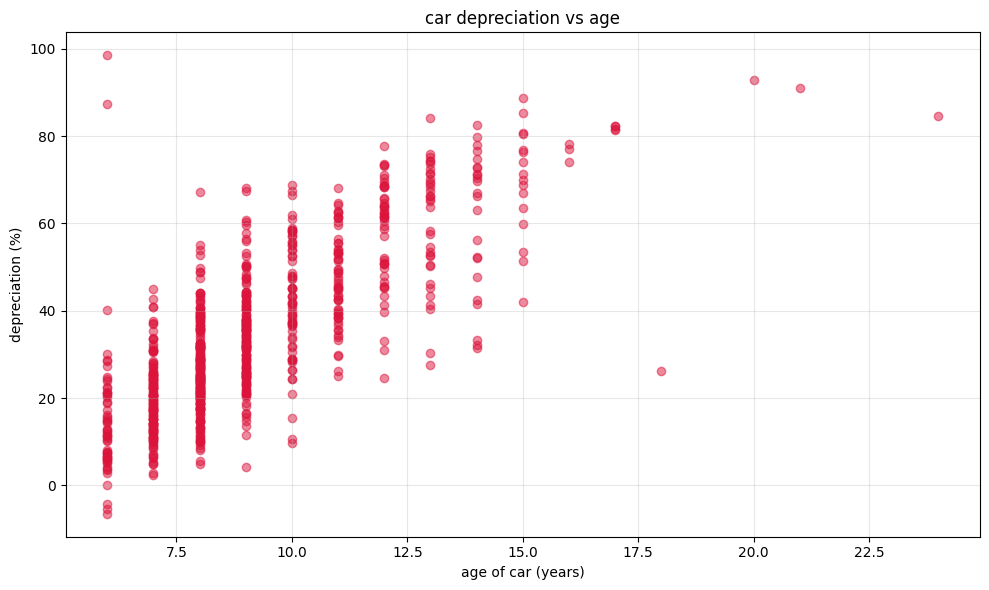

In [79]:
# new_price for depreciation estimation
import re

df_with_new_price = df[df['New_Price'].notna()].copy()

def parse_price_to_lakh(x):
    """
    Parse New_Price strings like '8.61 Lakh', '21 Lakh', '2.5 Cr' to numeric value in lakhs.
    Returns np.nan if parsing fails.
    """
    try:
        s = str(x).strip()
        # extract first numeric token (handles commas and decimals)
        m = re.search(r'([\d,]+(?:\.\d+)?)', s)
        if not m:
            return np.nan
        num = float(m.group(1).replace(',', ''))
        lower = s.lower()
        # if Crore/Cr -> convert to lakhs (1 Cr = 100 Lakhs)
        if 'crore' in lower or 'cr' in lower and 'lakh' not in lower:
            return num * 100.0
        # treat lakh/lac/lakh abbreviation or plain numbers as lakhs
        return num
    except Exception:
        return np.nan

if len(df_with_new_price) > 0:
    # create numeric versions
    df_with_new_price['New_Price_Num'] = df_with_new_price['New_Price'].apply(parse_price_to_lakh)
    df_with_new_price['Price_Num'] = pd.to_numeric(df_with_new_price['Price'], errors='coerce')
    
    # compute depreciation using numeric columns (in lakhs)
    df_with_new_price['Depreciation'] = df_with_new_price['New_Price_Num'] - df_with_new_price['Price_Num']
    df_with_new_price['Depreciation_Pct'] = (df_with_new_price['Depreciation'] / df_with_new_price['New_Price_Num']) * 100
    df_with_new_price['Age'] = 2025 - df_with_new_price['Year']
    
    print(f"depreciation analysis (based on {len(df_with_new_price)} cars with new_price data):\n")
    print(f"average depreciation: ₹{df_with_new_price['Depreciation'].mean():,.2f} lakhs")
    print(f"average depreciation %: {df_with_new_price['Depreciation_Pct'].mean():.2f}%")
    print(f"depreciation per year: ₹{(df_with_new_price['Depreciation'] / df_with_new_price['Age']).mean():,.2f} lakhs/year")
    
    # plot depreciation vs age (drop rows with missing percent)
    plot_df = df_with_new_price.dropna(subset=['Age', 'Depreciation_Pct'])
    if not plot_df.empty:
        plt.figure(figsize=(10, 6))
        plt.scatter(plot_df['Age'], plot_df['Depreciation_Pct'], alpha=0.5, color='crimson')
        plt.xlabel('age of car (years)')
        plt.ylabel('depreciation (%)')
        plt.title('car depreciation vs age')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("no valid rows to plot depreciation vs age")
else:
    print("insufficient new_price data for depreciation analysis")

In [80]:
# assess strong predictors of price
print("feature importance assessment for predicting price:\n")

# correlation-based ranking
price_corr_all = df[numerical_cols].corr()['Price'].abs().sort_values(ascending=False)
print("correlation with price (absolute values):")
print(price_corr_all)

print("\n" + "="*60)
print("\nstrong predictors (|correlation| > 0.3):")
strong_predictors = price_corr_all[price_corr_all > 0.3]
for feature, corr in strong_predictors.items():
    if feature != 'Price':
        print(f"  ✓ {feature}: {corr:.4f}")

print("\nweak predictors (|correlation| < 0.2):")
weak_predictors = price_corr_all[price_corr_all < 0.2]
for feature, corr in weak_predictors.items():
    if feature != 'Price':
        print(f"  ✗ {feature}: {corr:.4f}")

feature importance assessment for predicting price:



NameError: name 'numerical_cols' is not defined

---

### task 7: predictive readiness

In [ ]:
# mileage efficiency correlation with price and year
print("correlation of mileage with price and year:")
print(f"mileage vs price: {df['Mileage'].corr(df['Price']):.4f}")
print(f"mileage vs year: {df['Mileage'].corr(df['Year']):.4f}")

# analyze mileage trends over years
mileage_year = df.groupby('Year')['Mileage'].mean().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(mileage_year.index, mileage_year.values, marker='o', linewidth=2, color='darkgreen')
plt.xlabel('year of manufacture')
plt.ylabel('average mileage (kmpl)')
plt.title('mileage efficiency trend over manufacturing years')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nmileage improvement:")
print(f"early years (avg): {mileage_year.head(5).mean():.2f} kmpl")
print(f"recent years (avg): {mileage_year.tail(5).mean():.2f} kmpl")

In [ ]:
# average price by number of previous owners
avg_price_owner = df.groupby('Owner_Type')['Price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print("average price by owner type:")
print(avg_price_owner)

plt.figure(figsize=(10, 6))
avg_price_owner['mean'].plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('owner type')
plt.ylabel('average price (₹ lakhs)')
plt.title('average car price by number of previous owners')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# most and least expensive car models
print("most expensive cars:")
most_expensive = df.nlargest(10, 'Price')[['Name', 'Price', 'Year', 'Fuel_Type', 'Transmission', 'Power']]
print(most_expensive)

print("\n" + "="*80 + "\n")

print("least expensive cars:")
least_expensive = df.nsmallest(10, 'Price')[['Name', 'Price', 'Year', 'Fuel_Type', 'Transmission', 'Power']]
print(least_expensive)

---

### task 6: insights and trends

In [ ]:
# analyze new_price feature and missing data
new_price_missing = df['New_Price'].isna().sum()
new_price_pct = (new_price_missing / len(df)) * 100

print(f"new_price feature analysis:")
print(f"total missing values: {new_price_missing}")
print(f"percentage missing: {new_price_pct:.2f}%")
print(f"\navailable new_price entries: {len(df) - new_price_missing}")
print(f"percentage available: {100 - new_price_pct:.2f}%")

print(f"\nimpact on modeling:")
if new_price_pct > 50:
    print(f"⚠ with {new_price_pct:.1f}% missing, this feature may not be reliable")
    print(f"  consider dropping or using only for subset analysis")
else:
    print(f"✓ with {100-new_price_pct:.1f}% data available, feature could be useful")
    print(f"  can impute missing values or use as optional feature")

In [ ]:
# data quality checks
print("data quality assessment:\n")

# check for non-numeric values in supposedly numeric columns
print("1. checking power column:")
print(f"   data type: {df['Power'].dtype}")
try:
    pd.to_numeric(df['Power'], errors='coerce').isna().sum()
    print(f"   non-numeric entries: {pd.to_numeric(df['Power'], errors='coerce').isna().sum()}")
except:
    print("   contains non-numeric values")

print("\n2. checking mileage column:")
print(f"   data type: {df['Mileage'].dtype}")
print(f"   sample values: {df['Mileage'].head(3).values}")

print("\n3. checking engine column:")
print(f"   data type: {df['Engine'].dtype}")
print(f"   sample values: {df['Engine'].head(3).values}")

In [ ]:
# identify outliers using IQR method
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# check outliers in key columns
for col in ['Price', 'Engine', 'Power']:
    count, lower, upper = detect_outliers(col)
    pct = (count / len(df)) * 100
    print(f"\n{col}:")
    print(f"  outliers: {count} ({pct:.2f}%)")
    print(f"  bounds: [{lower:.2f}, {upper:.2f}]")

---

### task 5: outliers and data quality

In [ ]:
# multivariate analysis: transmission and fuel type effect on price
pivot_data = df.groupby(['Transmission', 'Fuel_Type'])['Price'].mean().unstack()

plt.figure(figsize=(10, 6))
pivot_data.plot(kind='bar', width=0.8, edgecolor='black')
plt.xlabel('transmission type')
plt.ylabel('average price (₹ lakhs)')
plt.title('average price by transmission and fuel type')
plt.legend(title='fuel type')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\naverage price breakdown:")
print(pivot_data)

In [ ]:
# scatter plots: price vs key numerical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price vs mileage
axes[0, 0].scatter(df['Mileage'], df['Price'], alpha=0.5, color='blue', s=10)
axes[0, 0].set_xlabel('mileage (kmpl)')
axes[0, 0].set_ylabel('price (₹ lakhs)')
axes[0, 0].set_title('price vs mileage')
axes[0, 0].grid(True, alpha=0.3)

# price vs engine
axes[0, 1].scatter(df['Engine'], df['Price'], alpha=0.5, color='red', s=10)
axes[0, 1].set_xlabel('engine capacity (cc)')
axes[0, 1].set_ylabel('price (₹ lakhs)')
axes[0, 1].set_title('price vs engine capacity')
axes[0, 1].grid(True, alpha=0.3)

# price vs power
axes[1, 0].scatter(df['Power'], df['Price'], alpha=0.5, color='green', s=10)
axes[1, 0].set_xlabel('power (bhp)')
axes[1, 0].set_ylabel('price (₹ lakhs)')
axes[1, 0].set_title('price vs power')
axes[1, 0].grid(True, alpha=0.3)

# price vs kilometers driven
axes[1, 1].scatter(df['Kilometers_Driven'], df['Price'], alpha=0.5, color='purple', s=10)
axes[1, 1].set_xlabel('kilometers driven')
axes[1, 1].set_ylabel('price (₹ lakhs)')
axes[1, 1].set_title('price vs kilometers driven')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# correlation matrix for numerical columns
numerical_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('correlation matrix heatmap')
plt.tight_layout()
plt.show()

print("\nstrongest correlations with price:")
price_corr = corr_matrix['Price'].sort_values(ascending=False)
print(price_corr)

---

### task 4: correlation and feature relationships

In [ ]:
# price distributions across fuel types
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fuel_Type', y='Price', palette='viridis')
plt.xlabel('fuel type')
plt.ylabel('price (₹ lakhs)')
plt.title('price distribution by fuel type')
plt.tight_layout()
plt.show()

# average prices by fuel type
avg_price_fuel = df.groupby('Fuel_Type')['Price'].mean().sort_values(ascending=False)
print("\naverage price by fuel type:")
print(avg_price_fuel)

In [ ]:
# price distributions across different locations (top 8)
top_locations = df['Location'].value_counts().head(8).index
df_top_loc = df[df['Location'].isin(top_locations)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_loc, x='Location', y='Price', palette='Set2')
plt.xlabel('location')
plt.ylabel('price (₹ lakhs)')
plt.title('price distribution across top 8 locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()